In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/df_full.csv", nrows=500000)

In [3]:
df.head(10)

,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,202279,prior,3,5,9,8.0,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,202279,prior,3,5,9,8.0,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,202279,prior,3,5,9,8.0,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4,1,202279,prior,3,5,9,8.0,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5,0,202279,prior,3,5,9,8.0,Natural Sweetener,17,13,baking ingredients,pantry
5,2,17794,6,1,202279,prior,3,5,9,8.0,Carrots,83,4,fresh vegetables,produce
6,2,40141,7,1,202279,prior,3,5,9,8.0,Original Unflavored Gelatine Mix,105,13,doughs gelatins bake mixes,pantry
7,2,1819,8,1,202279,prior,3,5,9,8.0,All Natural No Stir Creamy Almond Butter,88,13,spreads,pantry
8,2,43668,9,0,202279,prior,3,5,9,8.0,Classic Blend Cole Slaw,123,4,packaged vegetables fruits,produce
9,3,33754,1,1,205970,prior,16,5,17,12.0,Total 2% with Strawberry Lowfat Greek Strained...,120,16,yogurt,dairy eggs


In [4]:
df.shape

(500000, 15)

In [5]:
df.isna().sum()

order_id                      0
product_id                    0
add_to_cart_order             0
reordered                     0
user_id                       0
eval_set                      0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    31974
product_name                  0
aisle_id                      0
department_id                 0
aisle                         0
department                    0
dtype: int64

In [6]:
len(df)

500000

In [7]:
df.aisle.value_counts()

aisle
fresh fruits                  56326
fresh vegetables              52073
packaged vegetables fruits    27347
yogurt                        22485
packaged cheese               14960
                              ...  
baby accessories                124
kitchen supplies                119
baby bath body care             115
beauty                           84
frozen juice                     65
Name: count, Length: 134, dtype: int64

In [8]:
df["aisle"].dtype

dtype('O')

In [9]:
df.head(20)

,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,202279,prior,3,5,9,8.0,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,202279,prior,3,5,9,8.0,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,202279,prior,3,5,9,8.0,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4,1,202279,prior,3,5,9,8.0,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5,0,202279,prior,3,5,9,8.0,Natural Sweetener,17,13,baking ingredients,pantry
5,2,17794,6,1,202279,prior,3,5,9,8.0,Carrots,83,4,fresh vegetables,produce
6,2,40141,7,1,202279,prior,3,5,9,8.0,Original Unflavored Gelatine Mix,105,13,doughs gelatins bake mixes,pantry
7,2,1819,8,1,202279,prior,3,5,9,8.0,All Natural No Stir Creamy Almond Butter,88,13,spreads,pantry
8,2,43668,9,0,202279,prior,3,5,9,8.0,Classic Blend Cole Slaw,123,4,packaged vegetables fruits,produce
9,3,33754,1,1,205970,prior,16,5,17,12.0,Total 2% with Strawberry Lowfat Greek Strained...,120,16,yogurt,dairy eggs


In [10]:
df.order_hour_of_day.value_counts().sort_index()

order_hour_of_day
0      3588
1      1828
2      1153
3       746
4       773
5      1198
6      4442
7     13453
8     28006
9     37905
10    41204
11    41532
12    40780
13    40158
14    42757
15    40367
16    38852
17    32602
18    25395
19    19367
20    15977
21    11708
22     9662
23     6547
Name: count, dtype: int64

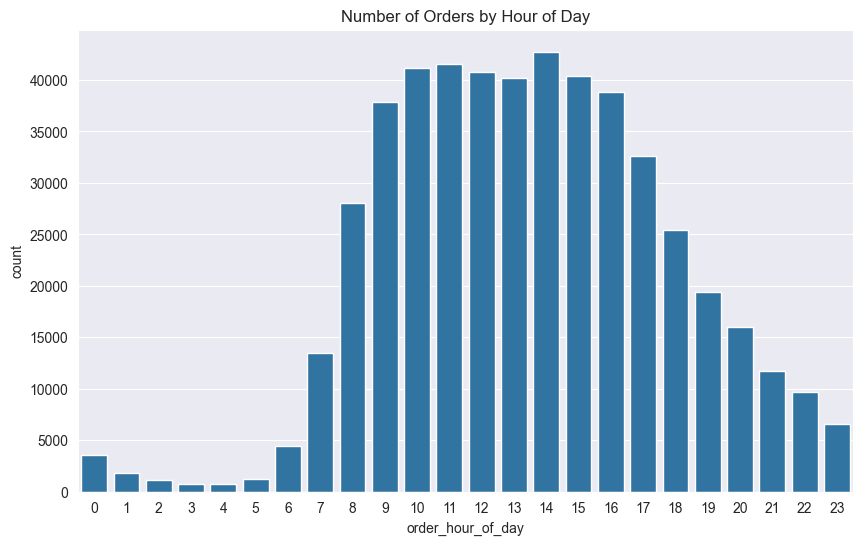

In [11]:
fig, ax = plt.subplots(figsize=(10,6))
sns.countplot(x='order_hour_of_day', data=df, ax=ax)
ax.set_title('Number of Orders by Hour of Day')
plt.show()

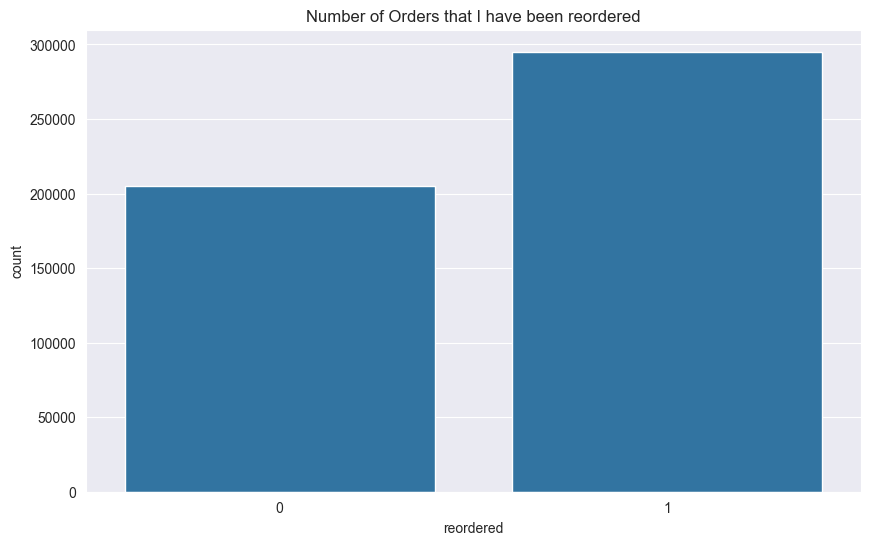

In [12]:
fig, ax = plt.subplots(figsize=(10,6))
sns.countplot(x='reordered', data=df, ax=ax)
ax.set_title('Number of Orders that I have been reordered')
plt.show()

In [13]:
df.reordered.value_counts(normalize=True)

reordered
1    0.590246
0    0.409754
Name: proportion, dtype: float64

In [14]:
df['aisle'].nunique()

134

In [15]:
df['department'].nunique()

21

In [16]:
df['product_name'].nunique()

29182

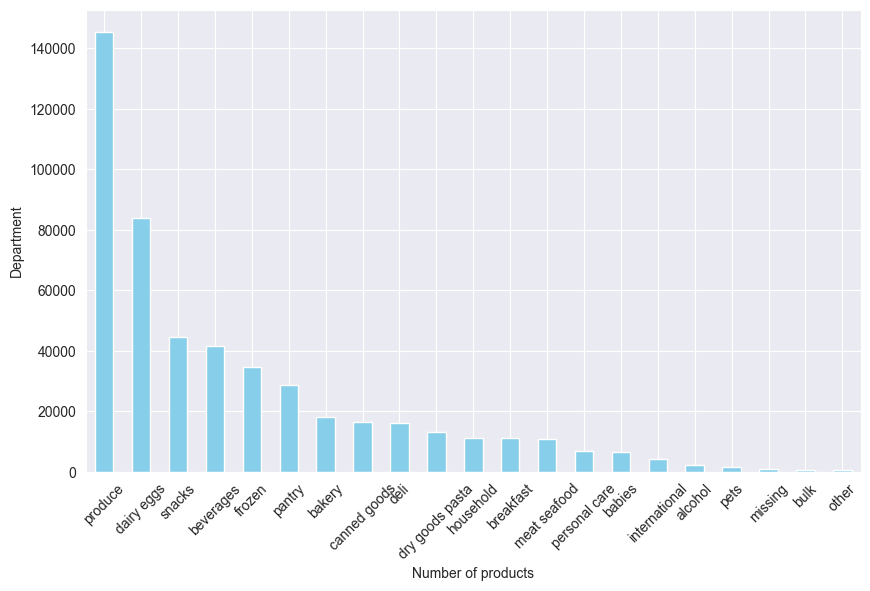

In [17]:
df['department'].value_counts().plot(kind='bar', color='skyblue', figsize=(10,6), rot=45)
plt.xlabel("Number of products")
plt.ylabel("Department")
plt.show()

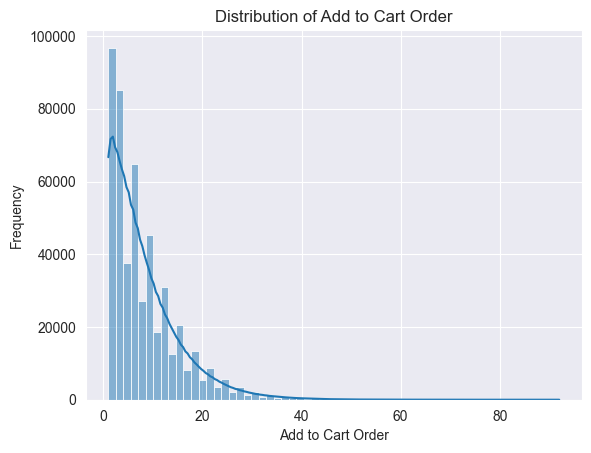

In [18]:
sns.histplot(x='add_to_cart_order', data=df, bins=60, kde=True)
plt.title("Distribution of Add to Cart Order")
plt.xlabel("Add to Cart Order")
plt.ylabel("Frequency")
plt.show()

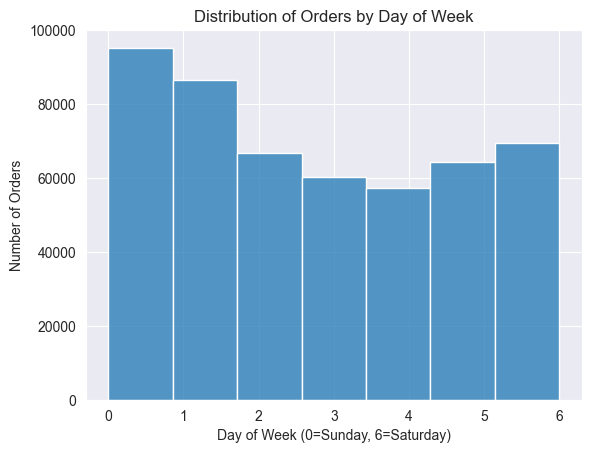

In [19]:
sns.histplot(x='order_dow', data=df, bins=7, kde=False)
plt.title("Distribution of Orders by Day of Week")
plt.xlabel("Day of Week (0=Sunday, 6=Saturday)")
plt.ylabel("Number of Orders")
plt.show()

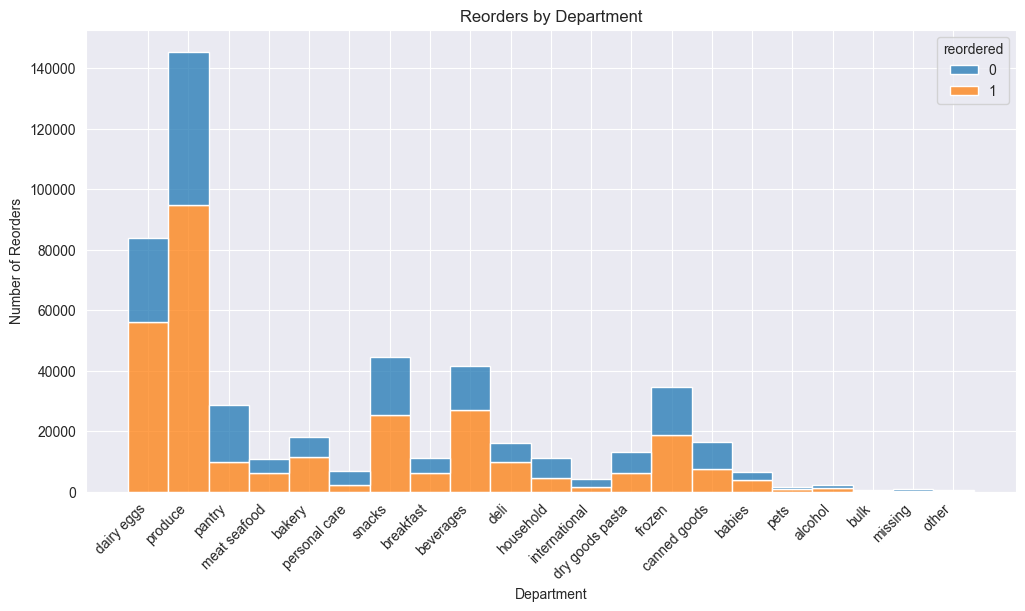

In [20]:
plt.figure(figsize=(12, 6))
sns.histplot(x='department', hue="reordered",data=df, multiple="stack")
plt.title("Reorders by Department")
plt.xlabel("Department")
plt.ylabel("Number of Reorders")
plt.xticks(rotation=45, ha='right')
plt.show()

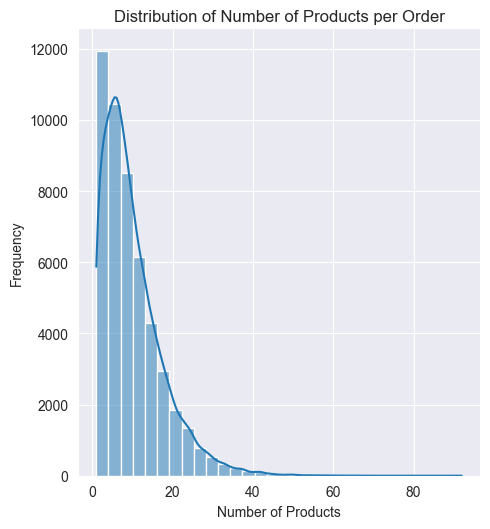

In [21]:
sns.displot(df.groupby('order_id').size(), bins=30, kde=True)
plt.title("Distribution of Number of Products per Order")
plt.xlabel("Number of Products")
plt.ylabel("Frequency")
plt.show()

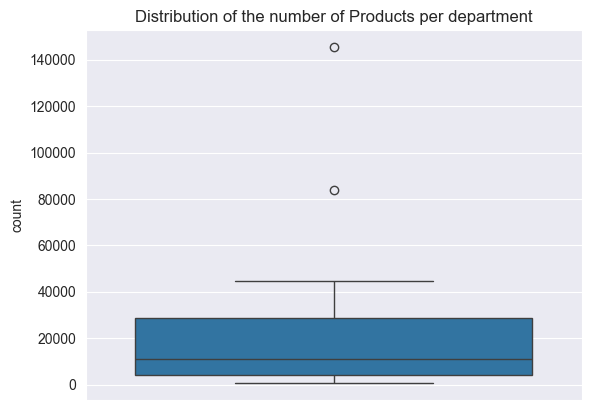

In [22]:
sns.boxplot(
    y=df['department'].value_counts()
)
plt.title("Distribution of the number of Products per department")
plt.show()

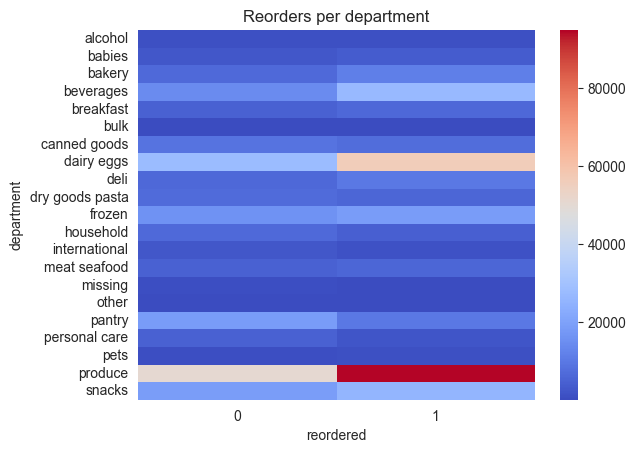

In [23]:
pivot = pd.crosstab(df['department'], df['reordered'])

sns.heatmap(pivot, cmap='coolwarm')
plt.title("Reorders per department")
plt.show()

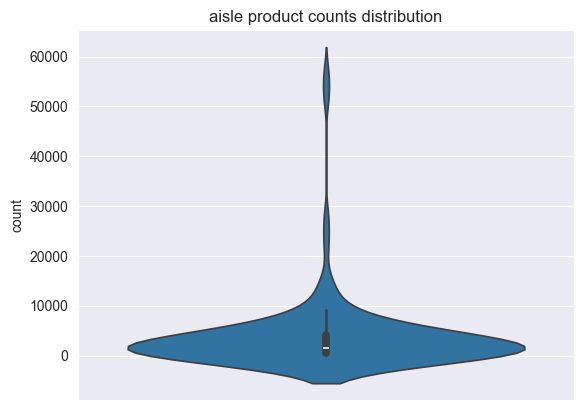

In [24]:
sns.violinplot(y=df['aisle'].value_counts())
plt.title("aisle product counts distribution")
plt.show()

### Reorder rate = average of reordered items

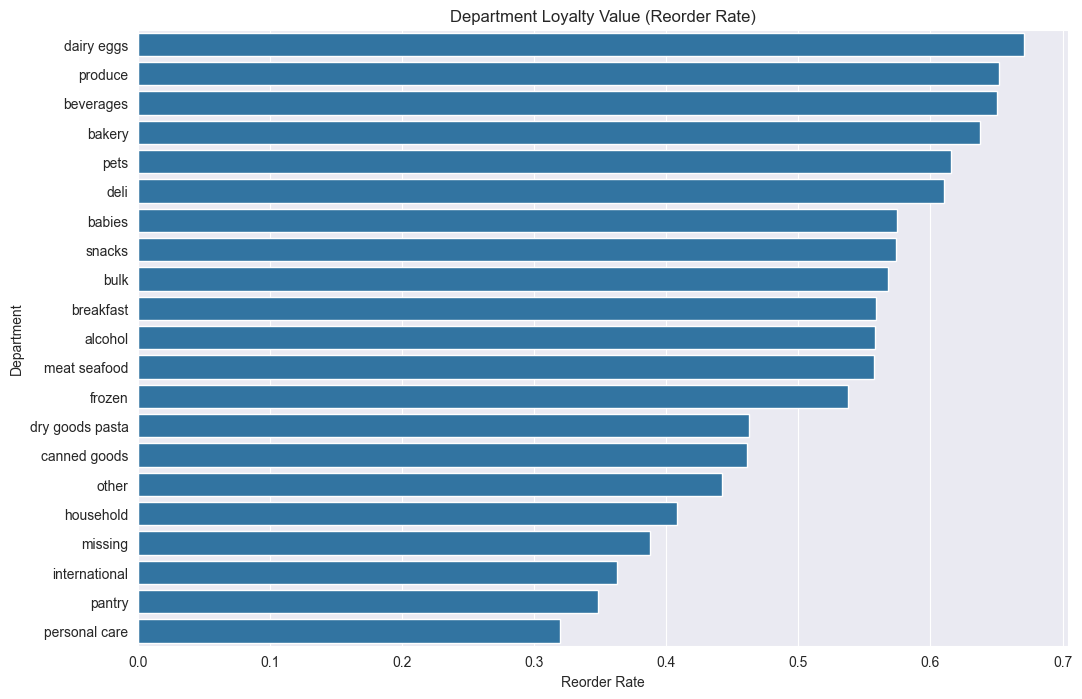

In [25]:
dept_reorder = (
    df
    .groupby('department')['reordered']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))
sns.barplot(x=dept_reorder.values, y=dept_reorder.index)
plt.title("Department Loyalty Value (Reorder Rate)")
plt.xlabel("Reorder Rate")
plt.ylabel("Department")
plt.show()


###  Average number of items per order by department

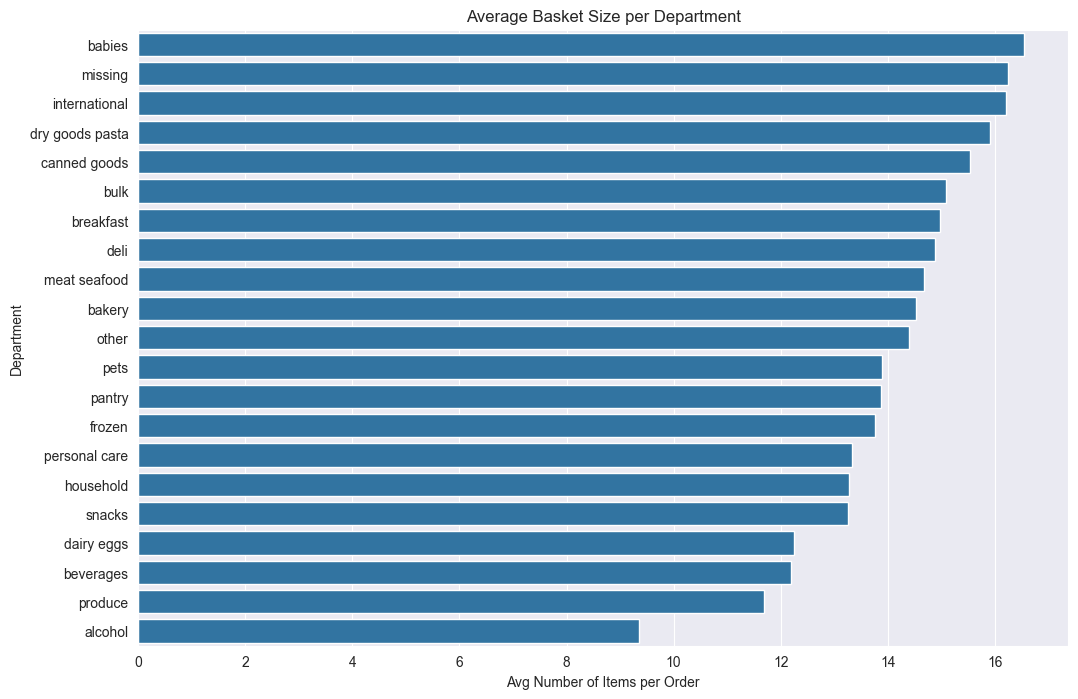

In [26]:
basket_size = df.groupby('order_id')['product_id'].count()

dept_basket = (
    df[['order_id', 'department']]
    .drop_duplicates()
    .merge(basket_size, on='order_id')
    .groupby('department')['product_id']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))
sns.barplot(x=dept_basket.values, y=dept_basket.index)
plt.title("Average Basket Size per Department")
plt.xlabel("Avg Number of Items per Order")
plt.ylabel("Department")
plt.show()

###  Average order per user

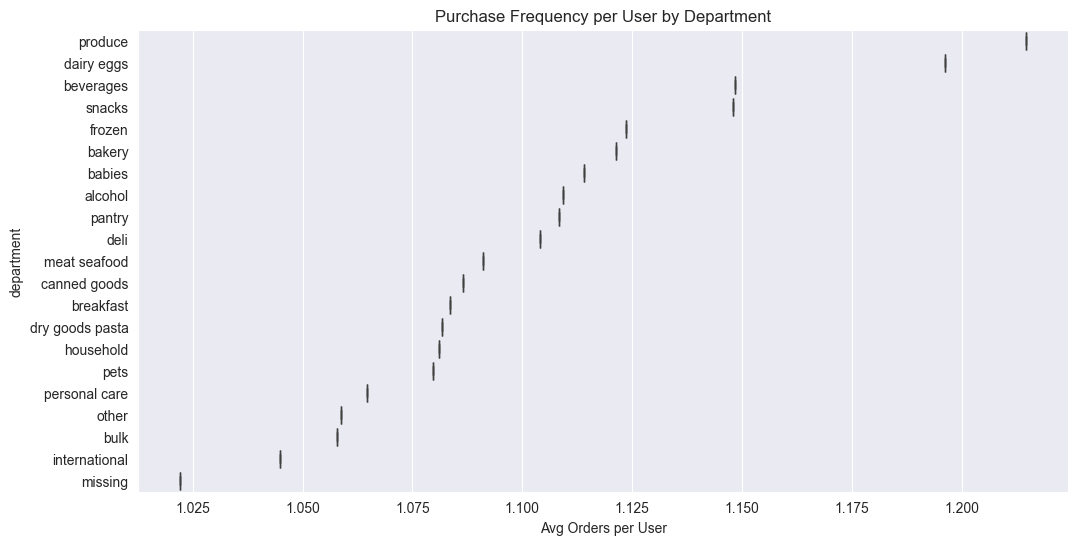

In [27]:
user_orders = (
    df[['user_id', 'order_id', 'department']]
    .drop_duplicates()
    .groupby(['department', 'user_id'])
    .count()
    .groupby('department')
    .mean()
    .sort_values('order_id', ascending=False)
)

plt.figure(figsize=(12,6))
sns.boxplot(data=user_orders, x='order_id', y=user_orders.index)
plt.title("Purchase Frequency per User by Department")
plt.xlabel("Avg Orders per User")
plt.show()

### Average basket size when the department is present vs global size

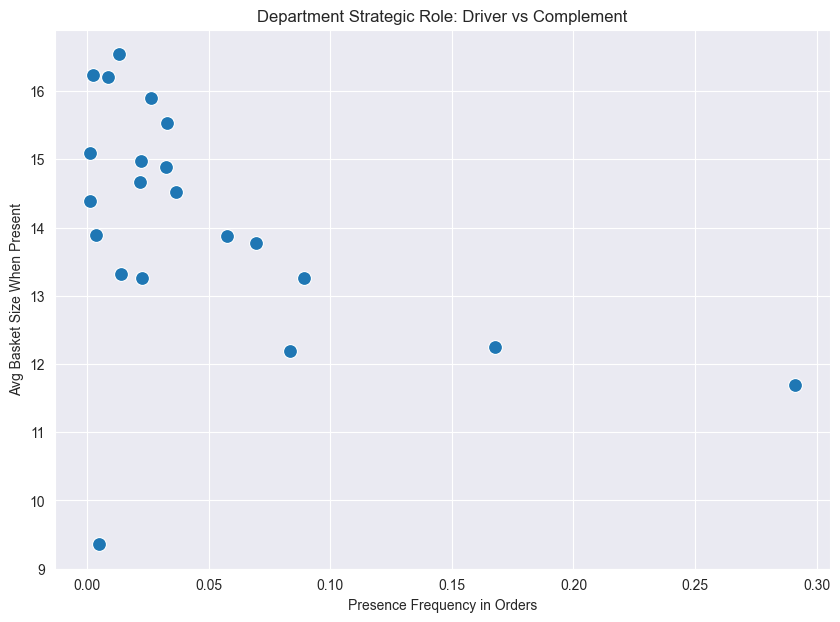

In [28]:
dept_orders = (
    df[['order_id', 'department']]
    .drop_duplicates()
)

basket_size_df = basket_size.reset_index(name='basket_size')

dept_driver = (
    dept_orders
    .merge(basket_size_df, on='order_id')
    .groupby('department')['basket_size']
    .mean()
    .sort_values(ascending=False)
)

dept_freq = df['department'].value_counts(normalize=True)

driver_df = pd.DataFrame({
    'freq': dept_freq,
    'basket_size': dept_driver
}).dropna()

plt.figure(figsize=(10,7))
sns.scatterplot(
    data=driver_df,
    x='freq',
    y='basket_size',
    s=100
)

plt.title("Department Strategic Role: Driver vs Complement")
plt.xlabel("Presence Frequency in Orders")
plt.ylabel("Avg Basket Size When Present")
plt.show()

### Final value graph with all value dimensions aggregated

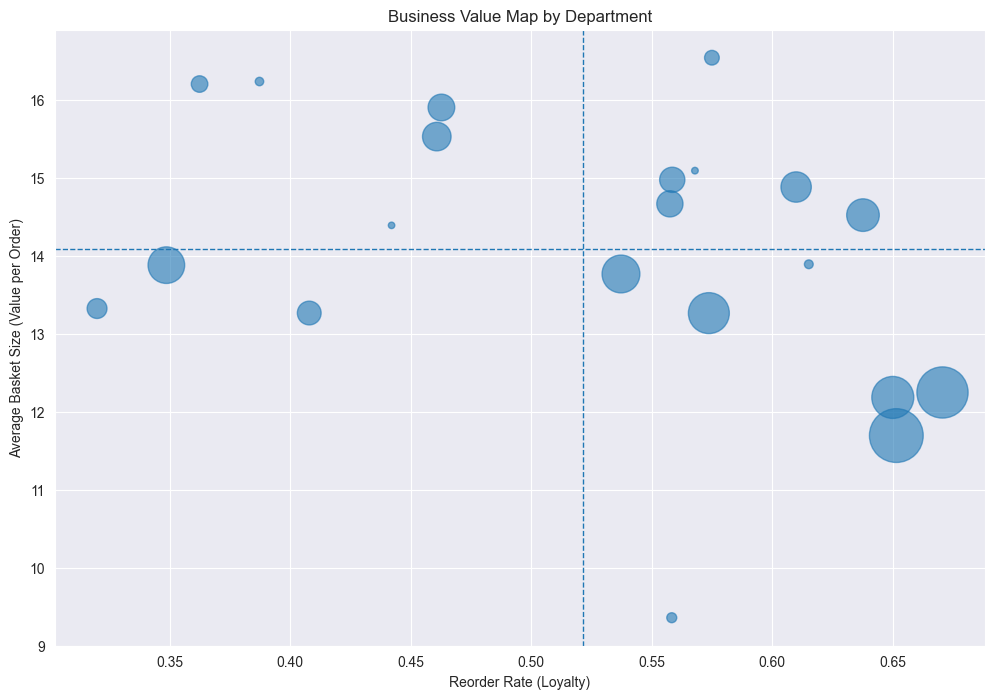

In [29]:
import matplotlib.pyplot as plt

# 1. Reorder rate per department (customer loyalty)
reorder_rate = (
    df
    .groupby('department')['reordered']
    .mean()
)

# 2. Basket size per department (value per order)
basket_size = (
    df
    .groupby('order_id')['product_id']
    .count()
    .reset_index(name='basket_size')
)

dept_basket = (
    df[['order_id', 'department']]
    .drop_duplicates()
    .merge(basket_size, on='order_id')
    .groupby('department')['basket_size']
    .mean()
)

# 3. Presence frequency per department (engagement)
dept_freq = (
    df[['order_id', 'department']]
    .drop_duplicates()
    .groupby('department')
    .size()
)

# 4. Final value DataFrame
value_df = pd.DataFrame({
    'reorder_rate': reorder_rate,
    'avg_basket_size': dept_basket,
    'order_freq': dept_freq
}).dropna()

# Normalize bubble sizes for better visualization
value_df['bubble_size'] = (
    value_df['order_freq'] / value_df['order_freq'].max()
) * 1500

plt.figure(figsize=(12,8))

plt.scatter(
    value_df['reorder_rate'],
    value_df['avg_basket_size'],
    s=value_df['bubble_size'],
    alpha=0.6
)

plt.xlabel("Reorder Rate (Loyalty)")
plt.ylabel("Average Basket Size (Value per Order)")
plt.title("Business Value Map by Department")

plt.axhline(value_df['avg_basket_size'].mean(), linestyle='--', linewidth=1)
plt.axvline(value_df['reorder_rate'].mean(), linestyle='--', linewidth=1)

plt.show()

This graph summarises the business value of departments according to their ability to build customer loyalty, increase basket size and structure purchase frequency. It identifies long-term value drivers independently of prices. This value map shows that business performance depends on a balance between departments that generate recurring revenue and departments that generate value per order. The growth drivers differ depending on the quadrant.

TOP Right - Value Champions
- High loyalty and high value per order and High frequency

TOP Left - Loyal Niches
- Big Basket Size but low frequency

BOTTOM Right - Popular Commodities
- High frequency but low basket size

BOTTOM Left - Low Value
- Low loyalty, low basket size, low frequency

